## Кластеризация


### Аудиторная работа

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram
from sklearn.cluster import DBSCAN

In [15]:
df = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/refs/heads/main/ML6.1%20clustering/data/mall_customers_clustering.csv', index_col=0)
df.head()

,CustomerID,Genre,Age,Income,Score
0,1,Male,19,15000,0.39
1,2,Male,21,15000,0.81
2,3,Female,20,16000,0.06
3,4,Female,23,16000,0.77
4,5,Female,31,17000,0.40


<Axes: xlabel='Income', ylabel='Score'>

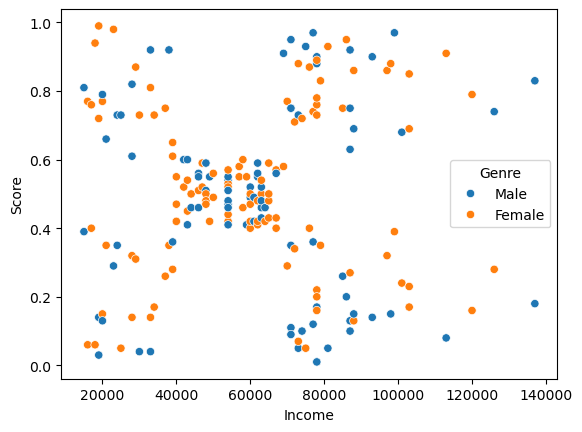

In [18]:
sns.scatterplot(x='Income' , y='Score',data=df , hue='Genre')

In [20]:
x = df.drop(["CustomerID"], axis=1)
X = pd.get_dummies(x)

In [22]:
k_means = KMeans(n_clusters=3, random_state=42).fit(X)

C:\Users\Home\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [24]:
y_kmeans = k_means.labels_
y_kmeans

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1])

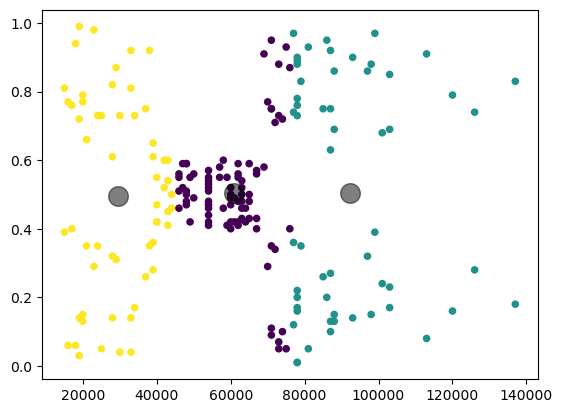

In [26]:
plt.scatter(x.Income, x.Score, c=y_kmeans, s=20, cmap='viridis')
centers = k_means.cluster_centers_
plt.scatter(centers[:, 1], centers[:, 2], c='black', s=200, alpha=0.5)

C:\Users\Home\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Home\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Home\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Home\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows wi

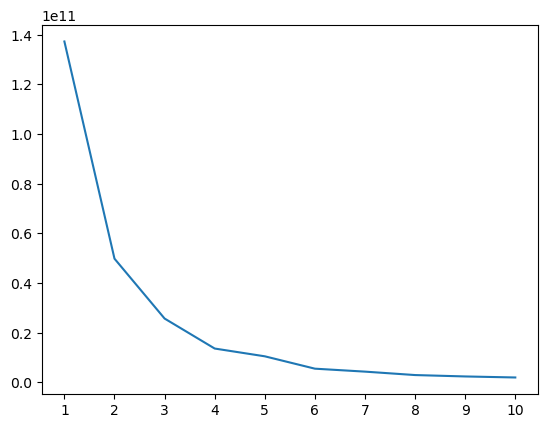

In [28]:
wcss = []
for i in range(1,11):
	k_means = KMeans(n_clusters=i,random_state=42)
	k_means.fit(X)
	wcss.append(k_means.inertia_)
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
_ = plt.show()

In [30]:
k_means = KMeans(n_clusters=4, random_state=42).fit(X)

C:\Users\Home\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


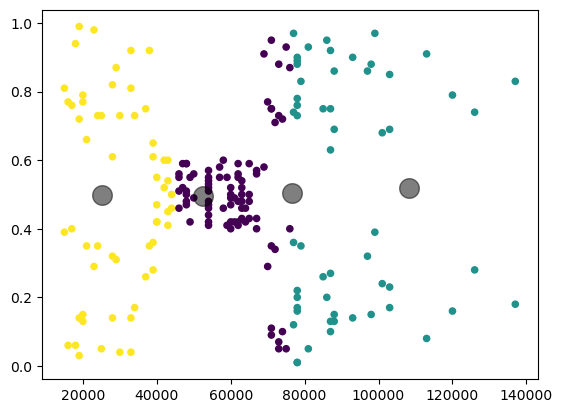

In [32]:
plt.scatter(x.Income, x.Score, c=y_kmeans, s=20, cmap='viridis')
centers = k_means.cluster_centers_
plt.scatter(centers[:, 1], centers[:, 2], c='black', s=200, alpha=0.5)

C:\Users\Home\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


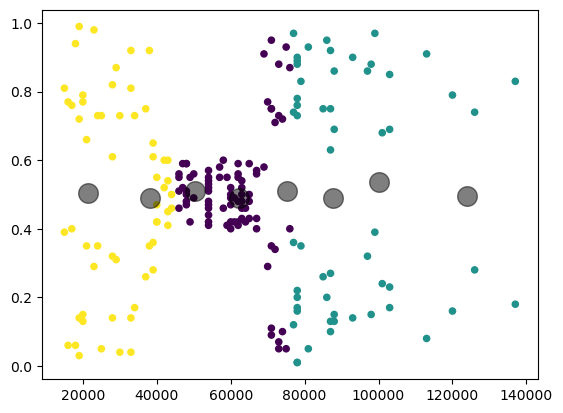

In [34]:
k_means = KMeans(n_clusters=8, random_state=42).fit(X)
plt.scatter(x.Income, x.Score, c=y_kmeans, s=20, cmap='viridis')
centers = k_means.cluster_centers_
plt.scatter(centers[:, 1], centers[:, 2], c='black', s=200, alpha=0.5)

#### Нормализация признаков

In [37]:
scaler = StandardScaler().fit(X)
X_scaled = scaler.transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,Age,Income,Score,Genre_Female,Genre_Male
0,-1.424569,-1.738999,-0.434801,-1.128152,1.128152
1,-1.281035,-1.738999,1.195704,-1.128152,1.128152
2,-1.352802,-1.700830,-1.715913,0.886405,-0.886405
3,-1.137502,-1.700830,1.040418,0.886405,-0.886405
4,-0.563369,-1.662660,-0.395980,0.886405,-0.886405


<Axes: xlabel='Income', ylabel='Score'>

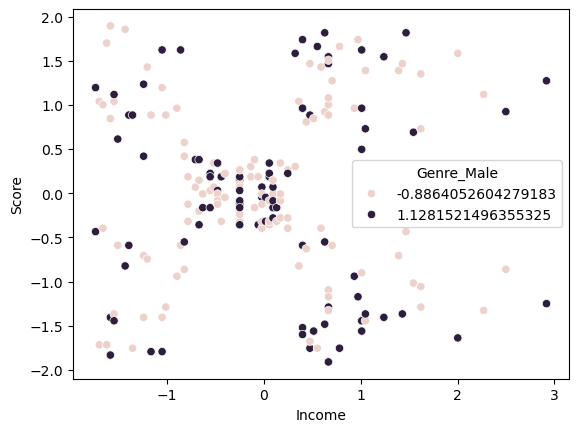

In [39]:
sns.scatterplot(x='Income' , y='Score',data=X_scaled , hue='Genre_Male')

C:\Users\Home\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Home\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Home\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Home\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows wi

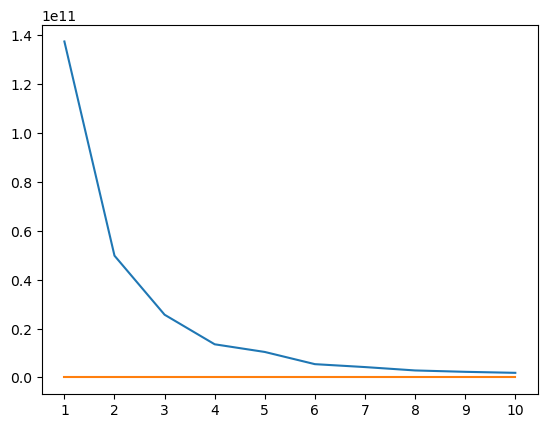

In [41]:
unscaled, scaled = [], []
for i in range(1,11):
	unscaled.append(KMeans(n_clusters=i,random_state=42).fit(X).inertia_)
	scaled.append(KMeans(n_clusters=i,random_state=42).fit(X_scaled).inertia_)
plt.plot(range(1,11),unscaled)
plt.plot(range(1,11),scaled)
plt.xticks(range(1,11))
_ = plt.show()

C:\Users\Home\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Home\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Home\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Home\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows wi

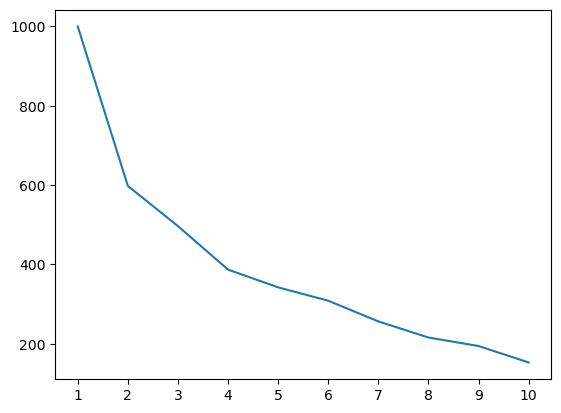

In [43]:
scaled = []
for i in range(1,11):
	scaled.append(KMeans(n_clusters=i,random_state=42).fit(X_scaled).inertia_)
plt.plot(range(1,11),scaled)
plt.xticks(range(1,11))
_ = plt.show()

C:\Users\Home\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


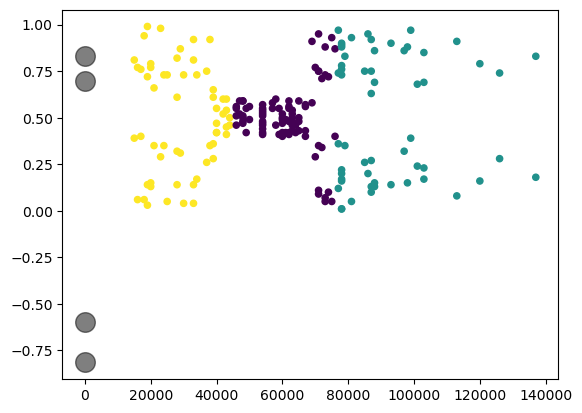

In [45]:
k_means = KMeans(n_clusters=4, random_state=42).fit(X_scaled)
plt.scatter(x.Income, x.Score, c=y_kmeans, s=20, cmap='viridis')
centers = k_means.cluster_centers_
plt.scatter(centers[:, 1], centers[:, 2], c='black', s=200, alpha=0.5)

In [47]:
X_flat = X_scaled.drop(["Age", "Genre_Female", "Genre_Male"], axis=1)
X_flat.head()

,Income,Score
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


C:\Users\Home\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Home\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Home\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Home\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows wi

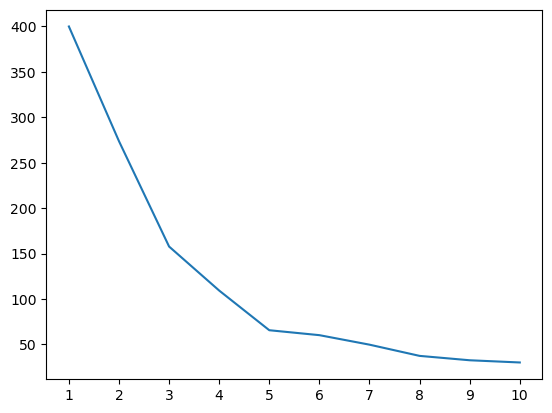

In [49]:
flat = []
for i in range(1,11):
	flat.append(KMeans(n_clusters=i,random_state=42).fit(X_flat).inertia_)
plt.plot(range(1,11),flat)
plt.xticks(range(1,11))
_ = plt.show()

C:\Users\Home\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


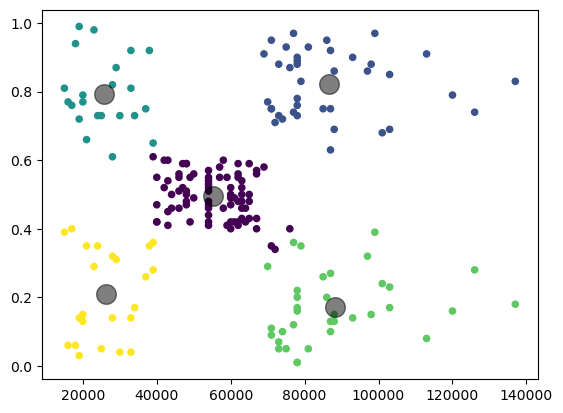

In [51]:
k_means = KMeans(n_clusters=5, random_state=42).fit(X_flat)
y_kmeans_flat = k_means.labels_
centers_scaled = k_means.cluster_centers_

income_idx_in_original_X = 1 # Index for 'Income' in the original X DataFrame
score_idx_in_original_X = 2  # Index for 'Score' in the original X DataFrame


centers_original_income = (centers_scaled[:, 0] * scaler.scale_[income_idx_in_original_X]) + scaler.mean_[income_idx_in_original_X]
centers_original_score = (centers_scaled[:, 1] * scaler.scale_[score_idx_in_original_X]) + scaler.mean_[score_idx_in_original_X]

plt.scatter(x.Income, x.Score, c=y_kmeans_flat, s=20, cmap='viridis')
plt.scatter(centers_original_income, centers_original_score, c='black', s=200, alpha=0.5)

#### Иерархическая кластеризация

In [54]:
model = AgglomerativeClustering(distance_threshold=0, n_clusters=None)
model = model.fit(X_scaled)

In [56]:
def plot_dendrogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    dendrogram(linkage_matrix, **kwargs)

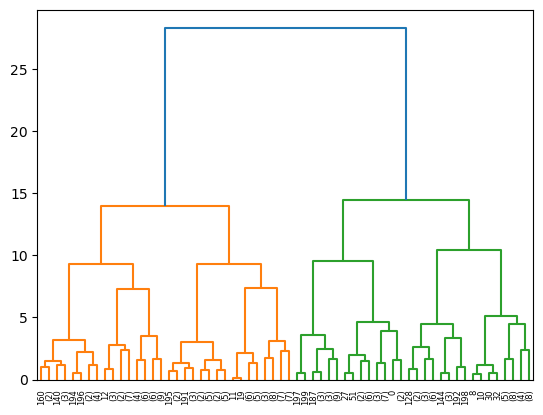

In [58]:
plot_dendrogram(model, truncate_mode="level", p=5)

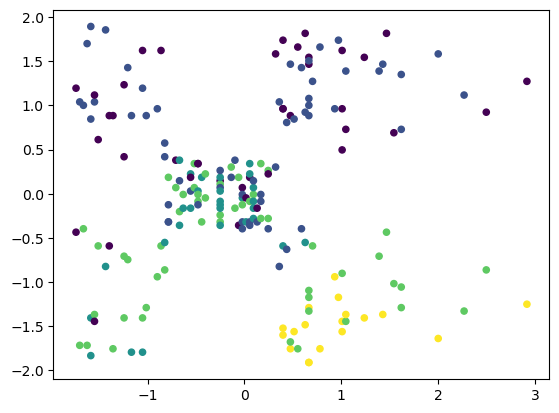

In [60]:
agg_clustering = AgglomerativeClustering(n_clusters=5).fit(X_scaled)
y_agg = agg_clustering.labels_

plt.scatter(X_flat.Income, X_flat.Score, c=y_agg, s=20, cmap='viridis')

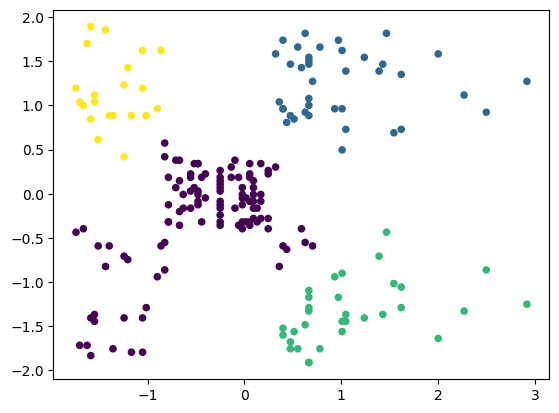

In [62]:
agg_clustering = AgglomerativeClustering(n_clusters=4).fit(X_flat)
y_agg = agg_clustering.labels_

plt.scatter(X_flat.Income, X_flat.Score, c=y_agg, s=20, cmap='viridis')

#### DBSCAN

In [65]:
db = DBSCAN(eps=0.4, min_samples=3).fit(X_flat)
y_db = db.labels_

In [67]:
n_clusters_ = len(set(y_db)) - (1 if -1 in y_db else 0)
n_noise_ = list(y_db).count(-1)

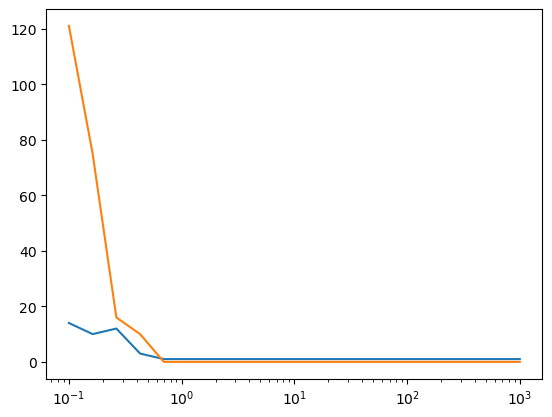

In [69]:
clusters, noise = [], []
for i in np.logspace(-1, 3, 20):
  db = DBSCAN(eps=i, min_samples=3).fit(X_flat)
  y_db = db.labels_

  clusters.append(len(set(y_db)) - (1 if -1 in y_db else 0))
  noise.append(list(y_db).count(-1))

plt.plot(np.logspace(-1, 3, 20),clusters)
plt.plot(np.logspace(-1, 3, 20),noise)
plt.xscale('log')
_ = plt.show()

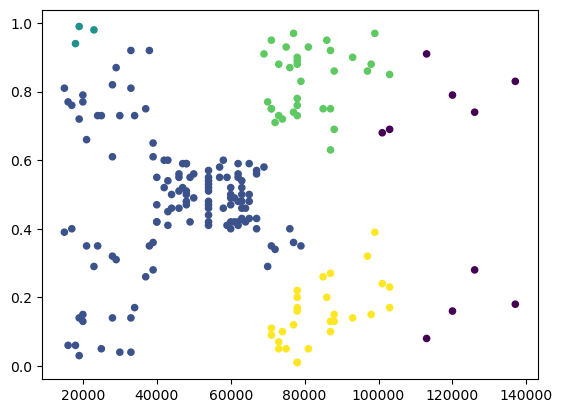

In [71]:
db = DBSCAN(eps=0.4, min_samples=3).fit(X_flat)
y_db = db.labels_

plt.scatter(X.Income, X.Score, c=y_db, s=20, cmap='viridis')

### Задания для самостоятельного выполнения

#### 1. Для придания смысла кластерам выведите примеры точек выборки для каждого кластера. Сделайте вывод, чем они отличаются.

In [80]:
df.head()

,CustomerID,Genre,Age,Income,Score
0,1,Male,19,15000,0.39
1,2,Male,21,15000,0.81
2,3,Female,20,16000,0.06
3,4,Female,23,16000,0.77
4,5,Female,31,17000,0.40


In [82]:
X_flat = X_scaled.drop(["Age", "Genre_Female", "Genre_Male"], axis=1)

In [84]:
X_flat.head()

,Income,Score
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


In [86]:
y_kmeans_flat

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1])

In [94]:
X_flat_clustered = X_flat.copy()
X_flat_clustered['Cluster'] = y_kmeans_flat

Среднее по кластерам

In [96]:
X_flat_clustered.groupby('Cluster').mean()

,Income,Score
Cluster,,
0,-0.200913,-0.026456
1,0.991583,1.239503
2,-1.329545,1.132178
3,1.055003,-1.284439
4,-1.307519,-1.136965


Каждый кластер

In [100]:
for cluster_id in sorted(X_flat_clustered['Cluster'].unique()):
    print(f'\nCluster {cluster_id}')
    display(X_flat_clustered[X_flat_clustered['Cluster'] == cluster_id].head())


Cluster 0


,Income,Score,Cluster
43,-0.822933,0.419273,0
46,-0.784763,0.186343,0
47,-0.784763,-0.124229,0
48,-0.784763,-0.318337,0
49,-0.784763,-0.318337,0



Cluster 1


,Income,Score,Cluster
123,0.322150,1.583920,1
125,0.360319,1.040418,1
127,0.398489,1.739206,1
129,0.398489,0.962775,1
131,0.398489,0.962775,1



Cluster 2


,Income,Score,Cluster
1,-1.738999,1.195704,2
3,-1.700830,1.040418,2
5,-1.662660,1.001596,2
7,-1.624491,1.700384,2
9,-1.586321,0.846310,2



Cluster 3


,Income,Score,Cluster
124,0.360319,-0.823017,3
128,0.398489,-1.521805,3
130,0.398489,-1.599448,3
134,0.474828,-1.754735,3
136,0.474828,-1.677091,3



Cluster 4


,Income,Score,Cluster
0,-1.738999,-0.434801,4
2,-1.700830,-1.715913,4
4,-1.662660,-0.395980,4
6,-1.624491,-1.715913,4
8,-1.586321,-1.832378,4


#### 2. Используйте для визуализации результатов кластеризации другие пары признаков. Сделайте вывод о зависимости кластеризации от признаков.

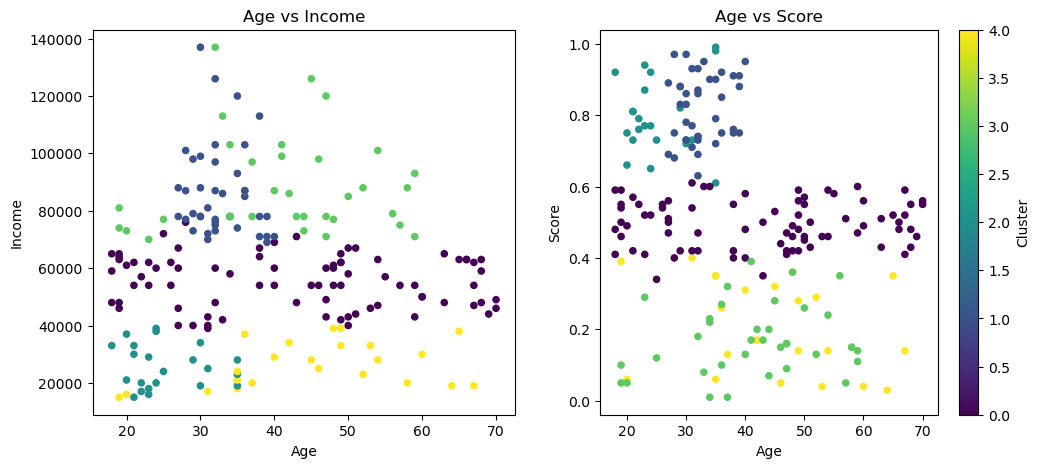

In [118]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(df['Age'], df['Income'], c=y_kmeans_flat, cmap='viridis', s=20)
plt.xlabel('Age')
plt.ylabel('Income')
plt.title('Age vs Income')

plt.subplot(1, 2, 2)
plt.scatter(df['Age'], df['Score'], c=y_kmeans_flat, cmap='viridis', s=20)
plt.xlabel('Age')
plt.ylabel('Score')
plt.title('Age vs Score')
plt.colorbar(label='Cluster')
plt.show()

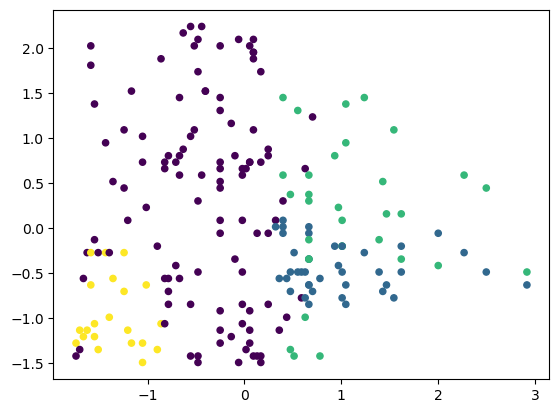

In [116]:
plt.scatter(X_scaled.Income, X_scaled.Age, c=y_agg, s=20, cmap='viridis')

#### 3. Повторите весь анализ для другого датасета - кластеризации кредитных карт.

In [120]:
df2= pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/refs/heads/main/ML6.1%20clustering/data/credit_card_clustering.csv', index_col=0)
df2.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
CUST_ID,,,,,,,,,,,,,,,,,
C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [126]:
X2 = df2.fillna(df2.mean())

X2_flat = X2[["CREDIT_LIMIT", "PURCHASES"]]
scaler2 = StandardScaler()
X2_flat_scaled = pd.DataFrame(scaler2.fit_transform(X2_flat), columns=X2_flat.columns)

In [138]:
k_means = KMeans(n_clusters=3, random_state=42).fit(X2)

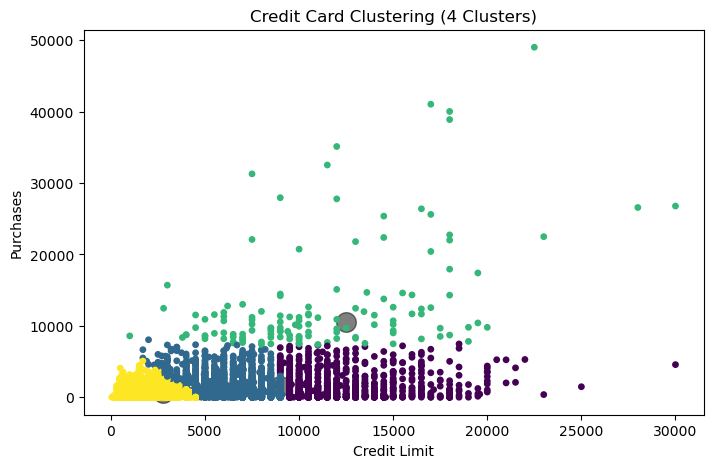

In [150]:
plt.figure(figsize=(8, 5))

centers = k_means.cluster_centers_
plt.scatter(centers[:, 12], centers[:, 2], c='black', s=200, alpha=0.5)

plt.scatter(X2_flat["CREDIT_LIMIT"], X2_flat["PURCHASES"], c=kmeans_cc.labels_, cmap='viridis', s=15)
plt.title('Credit Card Clustering (4 Clusters)')
plt.xlabel('Credit Limit')
plt.ylabel('Purchases')
plt.show()

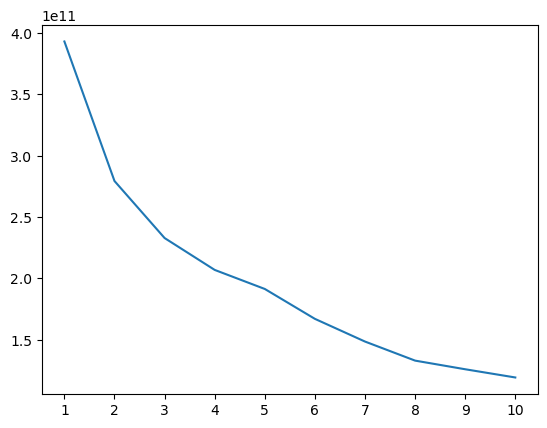

In [152]:
wcss = []
for i in range(1,11):
	k_means = KMeans(n_clusters=i,random_state=42)
	k_means.fit(X2)
	wcss.append(k_means.inertia_)
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
_ = plt.show()

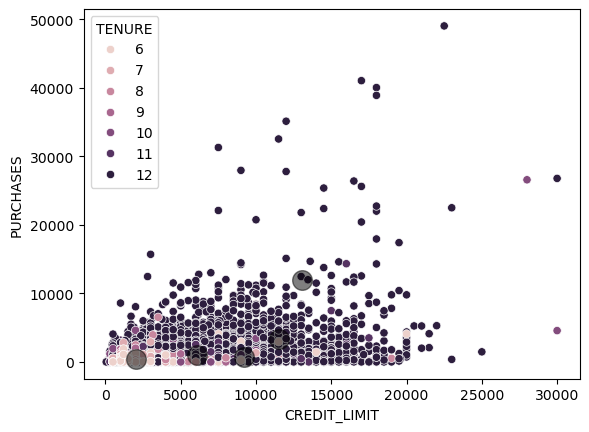

In [154]:
k_means = KMeans(n_clusters=5, random_state=42).fit(X2)
sns.scatterplot(x='CREDIT_LIMIT' , y='PURCHASES',data=df2 , hue='TENURE')
centers = k_means.cluster_centers_
plt.scatter(centers[:, 12], centers[:, 2], c='black', s=200, alpha=0.5)

In [156]:
scaler = StandardScaler().fit(X2)
X2_scaled = scaler.transform(X2)
X2_scaled = pd.DataFrame(X2_scaled, columns=X2.columns)
X2_scaled.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.731989,-0.249434,-0.424900,-0.356934,-0.349079,-0.466786,-0.806490,-0.678661,-0.707313,-0.675349,-0.476070,-0.511333,-0.960433,-0.528979,-3.109675e-01,-0.525551,0.36068
1,0.786961,0.134325,-0.469552,-0.356934,-0.454576,2.605605,-1.221758,-0.678661,-0.916995,0.573963,0.110074,-0.591796,0.688639,0.818642,8.931021e-02,0.234227,0.36068
2,0.447135,0.518084,-0.107668,0.108889,-0.454576,-0.466786,1.269843,2.673451,-0.916995,-0.675349,-0.476070,-0.109020,0.826062,-0.383805,-1.016632e-01,-0.525551,0.36068
3,0.049099,-1.016953,0.232058,0.546189,-0.454576,-0.368653,-1.014125,-0.399319,-0.916995,-0.258913,-0.329534,-0.551565,0.826062,-0.598688,4.878305e-17,-0.525551,0.36068
4,-0.358775,0.518084,-0.462063,-0.347294,-0.454576,-0.466786,-1.014125,-0.399319,-0.916995,-0.675349,-0.476070,-0.551565,-0.905464,-0.364368,-2.657913e-01,-0.525551,0.36068


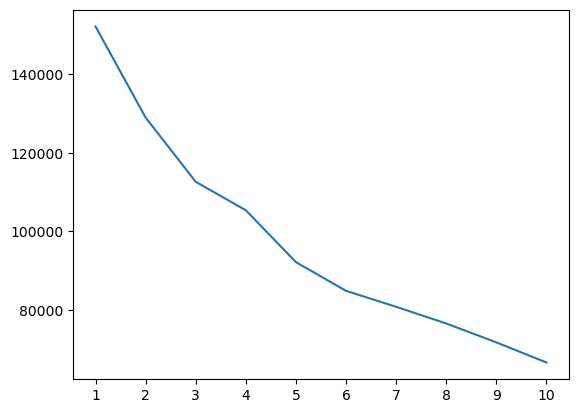

In [158]:
scaled = []
for i in range(1,11):
	scaled.append(KMeans(n_clusters=i,random_state=42).fit(X2_scaled).inertia_)
plt.plot(range(1,11),scaled)
plt.xticks(range(1,11))
_ = plt.show()

In [160]:
X2_flat = X2_scaled[["CREDIT_LIMIT", "PURCHASES"]]
X2_flat.head()

,CREDIT_LIMIT,PURCHASES
0,-0.960433,-0.424900
1,0.688639,-0.469552
2,0.826062,-0.107668
3,0.826062,0.232058
4,-0.905464,-0.462063


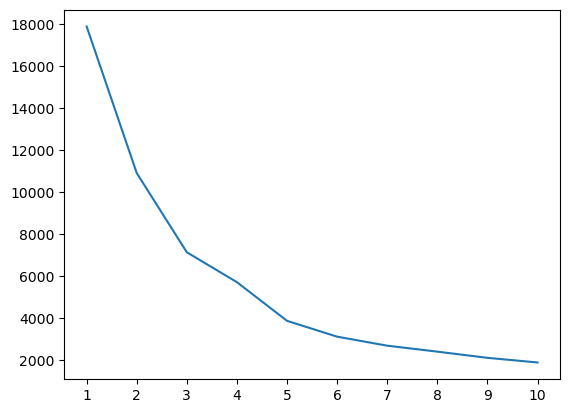

In [162]:
flat = []
for i in range(1,11):
	flat.append(KMeans(n_clusters=i,random_state=42).fit(X2_flat).inertia_)
plt.plot(range(1,11),flat)
plt.xticks(range(1,11))
_ = plt.show()

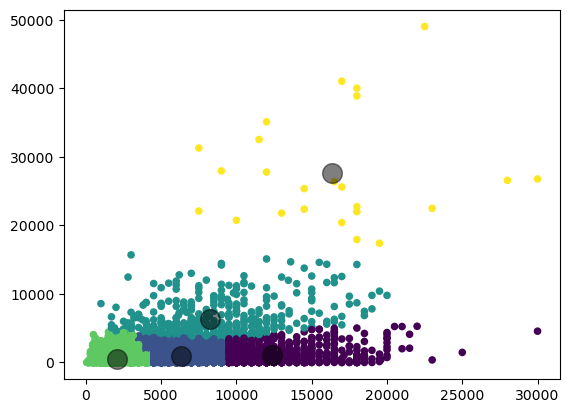

In [164]:
k_means = KMeans(n_clusters=5, random_state=42).fit(X2_flat)
y_kmeans_flat = k_means.labels_
centers_scaled = k_means.cluster_centers_

credit_limit_idx_in_X2 = X2.columns.get_loc("CREDIT_LIMIT")
purchases_idx_in_X2 = X2.columns.get_loc("PURCHASES")

centers_original_credit_limit = (centers_scaled[:, 0] * scaler.scale_[credit_limit_idx_in_X2]) + scaler.mean_[credit_limit_idx_in_X2]
centers_original_purchases = (centers_scaled[:, 1] * scaler.scale_[purchases_idx_in_X2]) + scaler.mean_[purchases_idx_in_X2]

plt.scatter(X2.CREDIT_LIMIT, X2.PURCHASES, c=y_kmeans_flat, s=20, cmap='viridis')
plt.scatter(centers_original_credit_limit, centers_original_purchases, c='black', s=200, alpha=0.5)

In [166]:
model = AgglomerativeClustering(distance_threshold=0, n_clusters=None)
model = model.fit(X2_scaled)

In [167]:
def plot_dendrogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    dendrogram(linkage_matrix, **kwargs)

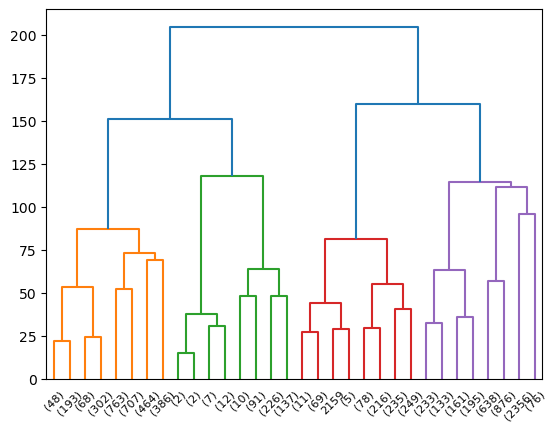

In [172]:
plot_dendrogram(model, truncate_mode="level", p=4)

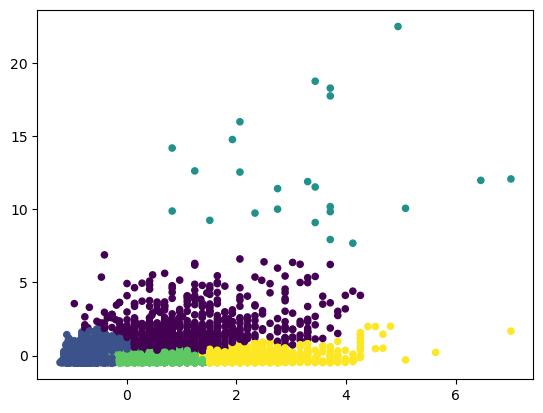

In [174]:
agg_clustering = AgglomerativeClustering(n_clusters=5).fit(X2_flat)
y_agg = agg_clustering.labels_
plt.scatter(X2_flat.CREDIT_LIMIT, X2_flat.PURCHASES, c=y_agg, s=20, cmap='viridis')

In [175]:
db = DBSCAN(eps=0.4, min_samples=3).fit(X2_flat)
y_db = db.labels_
n_clusters_ = len(set(y_db)) - (1 if -1 in y_db else 0)
n_noise_ = list(y_db).count(-1)

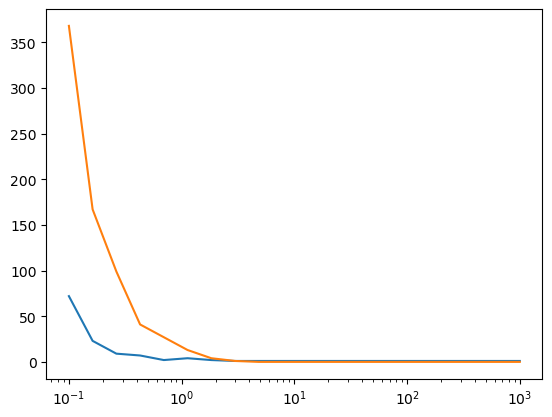

In [178]:
clusters, noise = [], []
for i in np.logspace(-1, 3, 20):
  db = DBSCAN(eps=i, min_samples=3).fit(X2_flat)
  y_db = db.labels_

  clusters.append(len(set(y_db)) - (1 if -1 in y_db else 0))
  noise.append(list(y_db).count(-1))

plt.plot(np.logspace(-1, 3, 20),clusters)
plt.plot(np.logspace(-1, 3, 20),noise)
plt.xscale('log')
_ = plt.show()

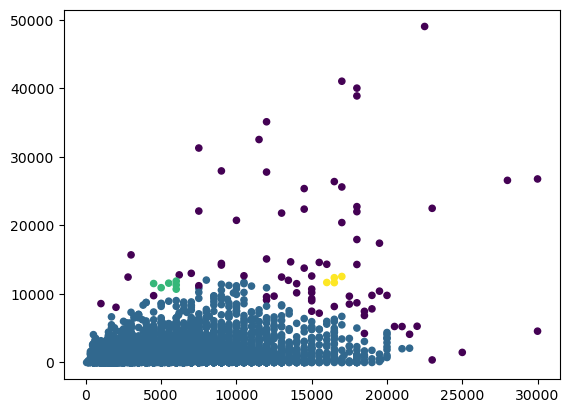

In [179]:
db = DBSCAN(eps=0.4, min_samples=4).fit(X2_flat)
y_db = db.labels_

plt.scatter(X2.CREDIT_LIMIT, X2.PURCHASES, c=y_db, s=20, cmap='viridis')

#### 4. В задании на иерархическую кластеризацию используйте разные методы расчета расстояния между кластерами. Сделайте выводы.

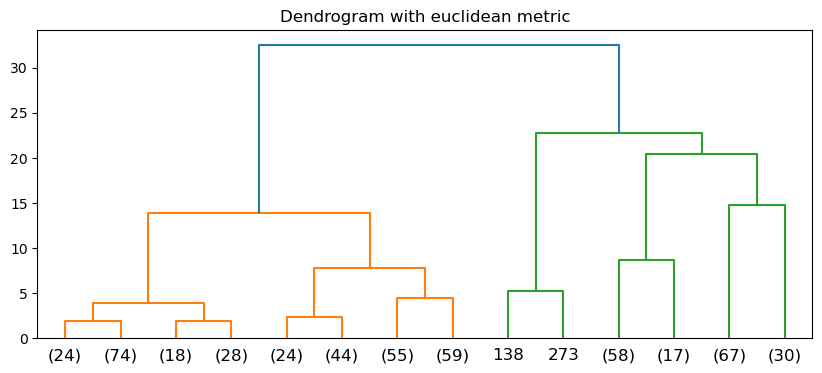

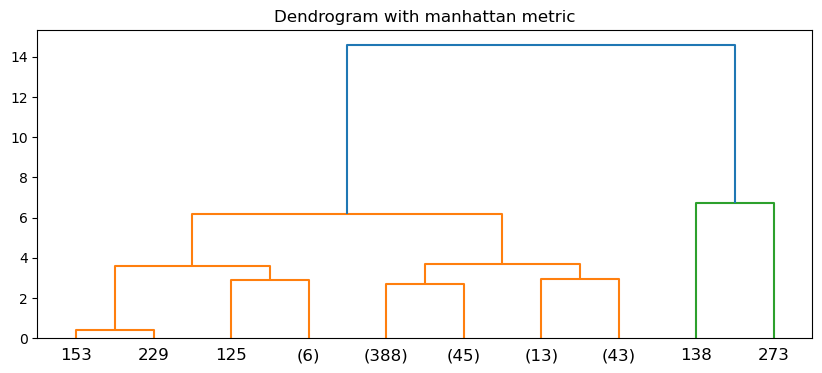

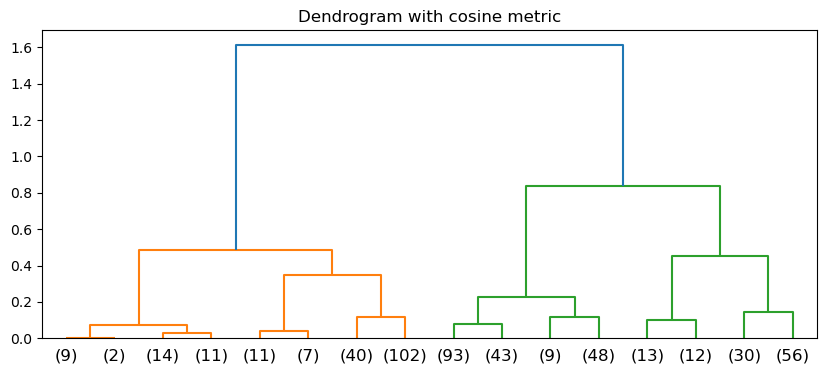

In [182]:
metrics = ['euclidean', 'manhattan', 'cosine']
for metric in metrics:
    linkage = 'ward' if metric == 'euclidean' else 'average'
    model = AgglomerativeClustering(distance_threshold=0, n_clusters=None, metric=metric, linkage=linkage)
    model.fit(X2_flat_scaled.head(500))
    
    plt.figure(figsize=(10, 4))
    plot_dendrogram(model, truncate_mode='level', p=3)
    plt.title(f'Dendrogram with {metric} metric')
    plt.show()

#### 5. В задании на DBSCAN вычислите метрику WCSS и соотнесите результаты кластеризации через DBSCAN и К-средних.

In [202]:
def calculate_dbscan_wcss(X, labels):
    X_arr = np.array(X)
    wcss = 0
    unique_labels = set(labels) - {-1}
    for label in unique_labels:
        cluster_points = X_arr[labels == label]
        center = cluster_points.mean(axis=0)
        wcss += np.sum((cluster_points - center) ** 2)
    return wcss

In [192]:
k_means = KMeans(n_clusters=5, random_state=42).fit(X_flat)
db = DBSCAN(eps=0.4, min_samples=3).fit(X_flat)

C:\Users\Home\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [194]:
wcss_kmeans = k_means.inertia_
wcss_dbscan_scalar = calculate_dbscan_wcss(X_flat, db.labels_)

In [196]:
print(f"WCSS K-means: {wcss_kmeans:.2f}")
print(f"WCSS DBSCAN: {wcss_dbscan_scalar:.2f}")

WCSS K-means: 65.57
WCSS DBSCAN: 128.74


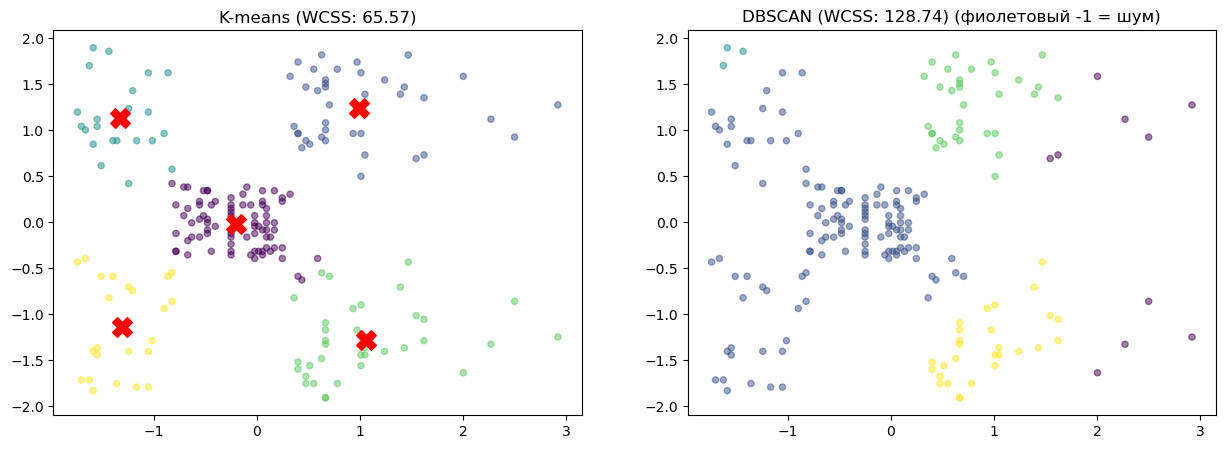

In [198]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
centers = k_means.cluster_centers_

ax1.set_title(f'K-means (WCSS: {wcss_kmeans:.2f})')
ax1.scatter(X_flat.iloc[:, 0], X_flat.iloc[:, 1], c=y_kmeans_flat, cmap='viridis', s=20, alpha=0.5)
ax1.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=200)

ax2.set_title(f'DBSCAN (WCSS: {wcss_dbscan_scalar:.2f}) (фиолетовый -1 = шум)')
ax2.scatter(X_flat.iloc[:, 0], X_flat.iloc[:, 1], c=y_db, cmap='viridis', s=20, alpha=0.5)
plt.show()

#### 6. Постройте кривые WCSS в зависимости от параметров DBSCAN.

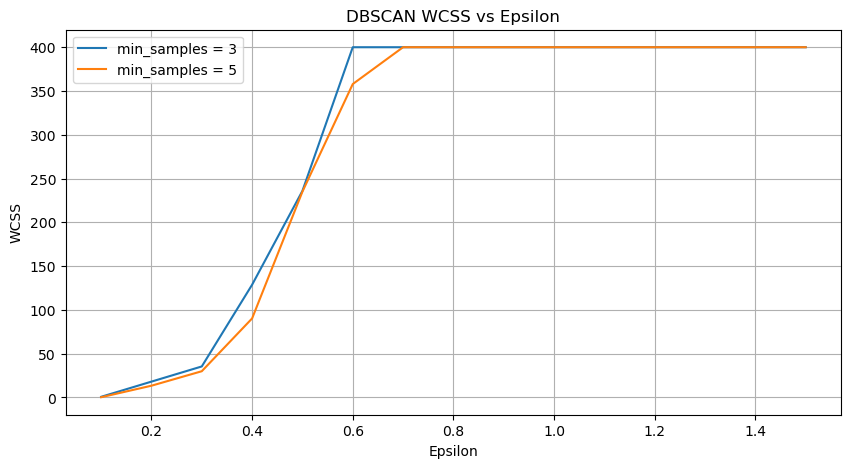

In [200]:
eps_values = np.linspace(0.1, 1.5, 15)
min_samples_values = [3, 5]

plt.figure(figsize=(10, 5))
for min_samples in min_samples_values:
    wcss_for_min_samples = []
    for eps in eps_values:
        db = DBSCAN(eps=eps, min_samples=min_samples).fit(X_flat)
        wcss_for_min_samples.append(calculate_dbscan_wcss(X_flat, db.labels_))
    plt.plot(eps_values, wcss_for_min_samples, label=f'min_samples = {min_samples}')

plt.title('DBSCAN WCSS vs Epsilon')
plt.xlabel('Epsilon')
plt.ylabel('WCSS')
plt.legend()
plt.grid(True)
plt.show()